# Generación de clusters

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

### Red para cluster 

In [2]:
red = gpd.read_file("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/asignacion_atributos/resultados_asignacion_atributos/asginacion_atributos_agebs_redcompleta/red_clustering_agebs.shp")

### Variables para el clustering

El análisis utilizará 7 variables:

1. Número de carriles
2. Capacidad
4. Velocidad límite (la velocidad promedio para un primer modelo no la consideramos porque representan dos medidas de velocidad relacionadas y darían mayor peso a la dimensión de velocidad.)
5. Densidad de población
6. Densidad de empleos
7. Distancia al centro de Guadalajara

In [3]:
columnas_clustering = ["cap_final", "carr_final", "vel_final", "dens_pob", "dens_emp", "dist_gdl"]


### Links del clustering

La red ya contiene una clasificación en la columna `cluster`. Los valores `-1` y `-2` son links excluidos por no contar con atributos válidos o por no tener la correspondencia necesaria. Los valores faltantes representan los links que sí deben participar en el análisis de clustering.

In [4]:
red_clustering = red[red["cluster"].isna()].copy()

### Estandarización y PCA

Para evitar que las variables de mayor magnitud dominen el análisis, estandarizamos las columnas (restando su media y dividiendo entre su desviación estandar).

Posteriormente, realizamos un PCA para determinales cuantas componentes son necesarias para conservar la mayor parte de la información inicial de la red.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [6]:
X = red_clustering[columnas_clustering].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

pca_completo = PCA()
pca_completo.fit(X_escalado)

varianza_explicada = pca_completo.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

resultados_pca = pd.DataFrame({"componente": [f"PC{i}" for i in range(1, len(columnas_clustering) + 1)], "varianza_explicada": varianza_explicada, "varianza_acumulada": varianza_acumulada})
print(resultados_pca.to_string(index=False))

componente  varianza_explicada  varianza_acumulada
       PC1            0.377795            0.377795
       PC2            0.246741            0.624536
       PC3            0.157195            0.781731
       PC4            0.104349            0.886080
       PC5            0.071626            0.957706
       PC6            0.042294            1.000000


Las primeras tres componentes principales conservan aproximadamente el 78.17 % de la variabilidad contenida en las seis variables originales. Esto nos permite reducir la dimensionalidad del problema de seis a tres ejes, manteniendo la mayor parte de la información.

Para interpretar cada componente, se analizarán sus cargas (la dirección y la intensidad con la que cada variable original participa en la construcción de las componentes principales).

In [7]:
numero_componentes = 3

pca = PCA(n_components=numero_componentes)
componentes_pca = pca.fit_transform(X_escalado)

columnas_componentes = [f"PC{i}" for i in range(1, numero_componentes + 1)]
loadings_pca = pd.DataFrame(pca.components_.T, index=columnas_clustering, columns=columnas_componentes)

print(f"Varianza acumulada con {numero_componentes} componentes: {pca.explained_variance_ratio_.sum():.2%}")
print()
print(loadings_pca.round(3))

Varianza acumulada con 3 componentes: 78.17%

              PC1    PC2    PC3
cap_final   0.564  0.289 -0.057
carr_final  0.519  0.106  0.024
vel_final   0.386  0.485 -0.156
dens_pob    0.154 -0.429 -0.803
dens_emp    0.334 -0.409  0.571
dist_gdl   -0.359  0.564 -0.037


Los componentes los podemos interpretar de la siguiente manera:

- **PC1 (jerarquía y capacidad vial):** dominado por `cap_final`, `carr_final` y, en menor medida, `vel_final`. Valores altos representan vialidades con mayor capacidad, más carriles y mayor velocidad.

- **PC2 (periferia y velocidad frente a densidad urbana):** aumenta con `dist_gdl` y `vel_final`, y disminuye con `dens_pob` y `dens_emp`. Valores altos representan vialidades más alejadas del centro, rápidas y ubicadas en zonas menos densas.

- **PC3 (contraste entre empleo y población):** tiene una carga negativa fuerte en `dens_pob` y positiva en `dens_emp`. Valores altos representan zonas con mayor concentración laboral relativa; valores bajos, zonas predominantemente residenciales.

## Clusters

### Número inicial de clusters

Las tres componentes principales representan la jerarquía vial, la relación entre centralidad y velocidad, y el contraste entre densidad laboral y residencial.

Antes de clasificar los links, evaluaremos los diferentes números de clusters mediante el método del codo (comparando la suma de las distancias cuadradas entre cada observación y el centro de su grupo producida por los K-menas, i.e., inercia).

Debido al tamaño de la red, esta evaluación se realizará sobre una muestra aleatoria reproducible. La muestra se utilizará únicamente para seleccionar el número de clusters.

In [8]:
from sklearn.cluster import KMeans

In [9]:
tamano_muestra = min(100000, len(componentes_pca))
generador = np.random.default_rng(42)
indices_muestra = generador.choice(len(componentes_pca), size=tamano_muestra, replace=False)
componentes_muestra = componentes_pca[indices_muestra]

valores_k = range(2, 11)
inercias = []

for k in valores_k:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_kmeans.fit(componentes_muestra)
    inercias.append(modelo_kmeans.inertia_)

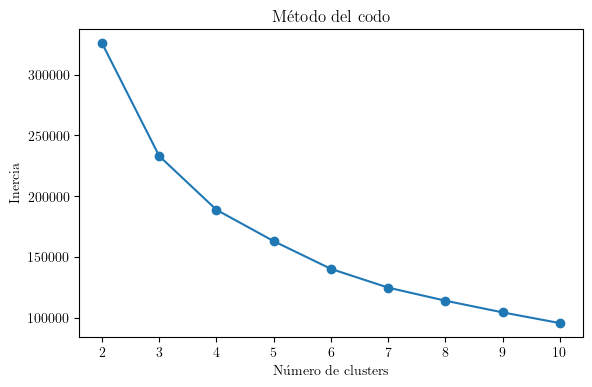

In [10]:
plt.figure(figsize=(6.5, 4))
plt.plot(valores_k, inercias, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(list(valores_k))
plt.show()

Vemos una caída drástica entre $k=2$ y $k=4$. Por lo que este método nos muestra que la mayor reducción de la inercia ocurre hasta aproximadamente cuatro o cinco clusters. Después de este punto, agregar grupos produce mejoras progresivamente menores.

Para hacer más sólida la selección final, comparamos las soluciones de cuatro, cinco y seis clusters mediante el coeficiente de silueta. Un valor mayor indica que los links están mejor cohesionados dentro de su grupo y más separados de los demás grupos.

In [11]:
from sklearn.metrics import silhouette_score

In [12]:
candidatos_k = [4, 5, 6]
resultados_silueta = []

for k in candidatos_k:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_muestra = modelo_kmeans.fit_predict(componentes_muestra)
    silueta = silhouette_score(componentes_muestra, etiquetas_muestra, sample_size=30000, random_state=42)
    resultados_silueta.append({"k": k, "silhouette_score": silueta})

resultados_silueta = pd.DataFrame(resultados_silueta)

print(resultados_silueta.to_string(index=False))

 k  silhouette_score
 4          0.363015
 5          0.374436
 6          0.315461


Con esto, entonces podemos concluir que la mejor solución entre las candidatas es $k=5$.

### Clustering principal con K-Means

Usaremos un modelo K-Means con cinco clusters utilizando las tres componentes principales de todos los links seleccionados.

Las etiquetas generadas por K-Means son identificadores numéricos. Posteriormente, cada cluster lo vamos a interpretar a partir de las medianas de sus variables originales.

In [13]:
numero_clusters = 5

modelo_kmeans = KMeans(n_clusters=numero_clusters, random_state=42, n_init=10)
etiquetas_clusters = modelo_kmeans.fit_predict(componentes_pca)

red_clustering["cluster"] = etiquetas_clusters + 1

In [14]:
conteo_clusters = red_clustering["cluster"].value_counts().sort_index()

print(conteo_clusters.to_string())
print()
print((conteo_clusters / len(red_clustering) * 100).round(2).astype(str) + " %")

cluster
1     13595
2     45387
3     39289
4    181642
5    176703

cluster
1     2.98 %
2     9.94 %
3      8.6 %
4    39.78 %
5     38.7 %
Name: count, dtype: object


Aquí vemos que ningún cluster quedó vacío y que los tamaños son razonables. Ahora, lo que hacemos es perfilar cada cluster con las variables originales. Así podremos saber qué representa cada grupo antes de subdividir alguno.

In [15]:
resumen_clusters = red_clustering.groupby("cluster")[columnas_clustering].median().round(2)
conteo_clusters = red_clustering["cluster"].value_counts().sort_index()

resumen_clusters.insert(0, "links", conteo_clusters)

print(resumen_clusters.to_string())

          links  cap_final  carr_final  vel_final  dens_pob  dens_emp  dist_gdl
cluster                                                                        
1         13595     5000.0         6.0       40.0   4301.25   2501.68      9.48
2         45387     2000.0         2.0       30.0   4007.31   7778.83      5.87
3         39289     4000.0         2.0       40.0   7444.44   1848.40     10.74
4        181642     2000.0         2.0       30.0   1424.41    292.16     19.10
5        176703     2000.0         2.0       30.0  12313.32   1754.28      9.68


In [16]:
import folium
from pathlib import Path
import webbrowser

In [17]:
carpeta_resultados = Path("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/asignacion_atributos/resultados_asignacion_atributos/asginacion_atributos_agebs_redcompleta")
ruta_html = carpeta_resultados / "clusters_red_vial.html"

colores_clusters = {1: "#e41a1c", 2: "#377eb8", 3: "#4daf4a", 4: "#984ea3", 5: "#ff7f00"}

red_html = red_clustering[["cluster", "geometry"]].to_crs(epsg=32613).copy()
red_html["geometry"] = red_html.geometry.simplify(tolerance=3, preserve_topology=True)
red_html = red_html.dissolve(by="cluster", as_index=False).to_crs(epsg=4326)

geometria_total = red_html.geometry.union_all()
centro_mapa = [geometria_total.centroid.y, geometria_total.centroid.x]

mapa_clusters = folium.Map(location=centro_mapa, zoom_start=10, tiles="CartoDB positron", prefer_canvas=True)

for cluster in sorted(red_html["cluster"].unique()):
    capa_cluster = red_html[red_html["cluster"] == cluster]
    folium.GeoJson(capa_cluster, name=f"Cluster {cluster}", style_function=lambda feature, color=colores_clusters[cluster]: {"color": color, "weight": 2, "opacity": 0.8}, tooltip=folium.GeoJsonTooltip(fields=["cluster"], aliases=["Cluster:"])).add_to(mapa_clusters)

limites = red_html.total_bounds
mapa_clusters.fit_bounds([[limites[1], limites[0]], [limites[3], limites[2]]])

folium.LayerControl(collapsed=False).add_to(mapa_clusters)

mapa_clusters.save(ruta_html)
webbrowser.open(ruta_html.as_uri())

print(f"Mapa guardado en: {ruta_html}")

Mapa guardado en: /Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/asignacion_atributos/resultados_asignacion_atributos/asginacion_atributos_agebs_redcompleta/clusters_red_vial.html


Aquí cada cluster lo podemos identificar de la siguiente forma:

- **Cluster 1:** vialidades de muy alta jerarquía, con mediana de 6 carriles y capacidad de 5,000.
- **Cluster 2:** vialidades centrales vinculadas con alta densidad de empleo. Es el grupo más cercano al centro.
- **Cluster 3:** vialidades de capacidad alta en zonas residenciales densas.
- **Cluster 4:** vialidades periféricas, con baja densidad de población y empleo y mayor distancia al centro.
- **Cluster 5:** vialidades locales o intermedias en zonas residenciales muy densas.

### Clusters candidatos a subdivisión

Hay muchos clusters que contienen una cantidad elevada de links y presentan y tienen una distribución poco homogenea. Por esto, evaluaremos la estructura de cada uno. 

Para cada uno se aplicará nuevamente la estandarización y el PCA utilizando las mismas seis variables originales.

In [18]:
clusters_a_subdividir = [1, 2, 3, 4, 5]
datos_subclusters = {}

for cluster in clusters_a_subdividir:
    red_cluster = red_clustering[red_clustering["cluster"] == cluster].copy()
    X_cluster = red_cluster[columnas_clustering].copy()

    escalador_cluster = StandardScaler()
    X_cluster_escalado = escalador_cluster.fit_transform(X_cluster)

    pca_cluster_completo = PCA()
    pca_cluster_completo.fit(X_cluster_escalado)

    resultados_pca_cluster = pd.DataFrame({"componente": [f"PC{i}" for i in range(1, len(columnas_clustering) + 1)], "varianza_explicada": pca_cluster_completo.explained_variance_ratio_, "varianza_acumulada": np.cumsum(pca_cluster_completo.explained_variance_ratio_)})
    datos_subclusters[cluster] = {"red": red_cluster, "X_escalado": X_cluster_escalado, "resultados_pca": resultados_pca_cluster}

    print(f"\nCluster {cluster}: {len(red_cluster):,} links")
    print(resultados_pca_cluster.to_string(index=False))


Cluster 1: 13,595 links
componente  varianza_explicada  varianza_acumulada
       PC1            0.490612            0.490612
       PC2            0.169096            0.659708
       PC3            0.153295            0.813003
       PC4            0.092934            0.905937
       PC5            0.060046            0.965983
       PC6            0.034017            1.000000

Cluster 2: 45,387 links
componente  varianza_explicada  varianza_acumulada
       PC1            0.266821            0.266821
       PC2            0.235355            0.502176
       PC3            0.174086            0.676262
       PC4            0.156986            0.833248
       PC5            0.087004            0.920252
       PC6            0.079748            1.000000

Cluster 3: 39,289 links
componente  varianza_explicada  varianza_acumulada
       PC1            0.311934            0.311934
       PC2            0.251818            0.563752
       PC3            0.156463            0.720215
       

Con esto podemos ver que todos los clusters conservan estructura interna suficiente para evaluarse como candidatos a subdivisión.

In [19]:
componentes_por_cluster = {1: 3, 2: 4, 3: 4, 4: 4, 5: 4}
modelos_subclusters = {}

for cluster, numero_componentes_cluster in componentes_por_cluster.items():
    red_cluster = red_clustering[red_clustering["cluster"] == cluster].copy()
    X_cluster = red_cluster[columnas_clustering].copy()

    escalador_cluster = StandardScaler()
    X_cluster_escalado = escalador_cluster.fit_transform(X_cluster)

    pca_cluster = PCA(n_components=numero_componentes_cluster)
    componentes_cluster = pca_cluster.fit_transform(X_cluster_escalado)

    modelos_subclusters[cluster] = {"red": red_cluster, "escalador": escalador_cluster, "pca": pca_cluster, "componentes": componentes_cluster}

    print(f"Cluster {cluster}: {len(red_cluster):,} links, {numero_componentes_cluster} componentes, varianza acumulada = {pca_cluster.explained_variance_ratio_.sum():.2%}")

Cluster 1: 13,595 links, 3 componentes, varianza acumulada = 81.30%
Cluster 2: 45,387 links, 4 componentes, varianza acumulada = 83.32%
Cluster 3: 39,289 links, 4 componentes, varianza acumulada = 84.72%
Cluster 4: 181,642 links, 4 componentes, varianza acumulada = 86.06%
Cluster 5: 176,703 links, 4 componentes, varianza acumulada = 83.85%


La diferencia es cuántas componentes debemos conservar dentro de cada uno:

- **Cluster 1:** tres componentes explican 81.30 %
- **Cluster 2:** cuatro componentes explican 83.32 %
- **Cluster 3:** cuatro componentes explican 84.72 %
- **Cluster 4:** cuatro componentes explican 86.06 %
- **Cluster 5:** cuatro componentes explican 83.85 %

Nuevamente buscamos el número de sublusters que debe de tener cada cluster a partir de los coeficientes de silueta.

In [20]:
resultados_silueta_subclusters = []

for cluster in componentes_por_cluster:
    componentes_cluster = modelos_subclusters[cluster]["componentes"]

    tamano_muestra_cluster = min(30000, len(componentes_cluster))
    generador = np.random.default_rng(42)
    indices_muestra_cluster = generador.choice(len(componentes_cluster), size=tamano_muestra_cluster, replace=False)
    componentes_muestra_cluster = componentes_cluster[indices_muestra_cluster]

    for numero_subclusters in range(2, 7):
        modelo_subcluster = KMeans(n_clusters=numero_subclusters, random_state=42, n_init=10)
        etiquetas_muestra_cluster = modelo_subcluster.fit_predict(componentes_muestra_cluster)
        silueta = silhouette_score(componentes_muestra_cluster, etiquetas_muestra_cluster, sample_size=min(10000, tamano_muestra_cluster), random_state=42)

        resultados_silueta_subclusters.append({"cluster": cluster, "numero_subclusters": numero_subclusters, "silhouette_score": silueta})

resultados_silueta_subclusters = pd.DataFrame(resultados_silueta_subclusters)

print(resultados_silueta_subclusters.to_string(index=False))

 cluster  numero_subclusters  silhouette_score
       1                   2          0.416948
       1                   3          0.359862
       1                   4          0.350910
       1                   5          0.364852
       1                   6          0.360545
       2                   2          0.500234
       2                   3          0.290938
       2                   4          0.300489
       2                   5          0.349340
       2                   6          0.369802
       3                   2          0.341411
       3                   3          0.281475
       3                   4          0.297320
       3                   5          0.323575
       3                   6          0.289542
       4                   2          0.450841
       4                   3          0.453780
       4                   4          0.377541
       4                   5          0.381173
       4                   6          0.365476
       5     

## Construcción de los subclusters

Los Clusters 1, 2, 3 y 5 se dividirán en dos subclusters. El Cluster 4 se dividirá en tres subclusters..

Los K-Means se ajustarán utilizando todos los links pertenecientes a cada cluster principal. La columna `subcluster` identificará la clasificación de segundo nivel dentro de cada grupo.

In [21]:
subclusters_por_cluster = {1: 2, 2: 2, 3: 2, 4: 3, 5: 2}

red_clustering["subcluster"] = 0

for cluster, numero_subclusters in subclusters_por_cluster.items():
    componentes_cluster = modelos_subclusters[cluster]["componentes"]
    indices_cluster = modelos_subclusters[cluster]["red"].index

    modelo_subcluster = KMeans(n_clusters=numero_subclusters, random_state=42, n_init=10)
    etiquetas_subcluster = modelo_subcluster.fit_predict(componentes_cluster) + 1

    red_clustering.loc[indices_cluster, "subcluster"] = etiquetas_subcluster
    modelos_subclusters[cluster]["kmeans"] = modelo_subcluster

In [22]:
conteo_subclusters = red_clustering.groupby(["cluster", "subcluster"]).size().rename("links")

print(conteo_subclusters.to_string())
print()
print(f"Links sin subcluster: {(red_clustering['subcluster'] == 0).sum():,}")

cluster  subcluster
1        1               4766
         2               8829
2        1              40714
         2               4673
3        1               7410
         2              31879
4        1              82047
         2              48322
         3              51273
5        1              42578
         2             134125

Links sin subcluster: 0


### Caracterización de los subclusters

Nuevamente calcularemos las medianas de las seis variables originales, para distinguir, dentro de cada cluster principal, diferencias en capacidad, número de carriles, velocidad, densidad poblacional, densidad de empleo y distancia al centro de Guadalajara.

In [23]:
resumen_subclusters = red_clustering.groupby(["cluster", "subcluster"])[columnas_clustering].median().round(2)
conteo_subclusters = red_clustering.groupby(["cluster", "subcluster"]).size().rename("links")

resumen_subclusters.insert(0, "links", conteo_subclusters)

print(resumen_subclusters.to_string())

                     links  cap_final  carr_final  vel_final  dens_pob  dens_emp  dist_gdl
cluster subcluster                                                                        
1       1             4766     4000.0         3.0       80.0    468.64    320.63     21.88
        2             8829     6000.0         6.0       40.0   6823.68   3743.90      6.71
2       1            40714     2000.0         2.0       30.0   4165.53   7355.98      5.98
        2             4673     3000.0         4.0       30.0   2819.36  12917.98      4.30
3       1             7410     3000.0         4.0       30.0   6674.32   1905.63     10.08
        2            31879     4000.0         2.0       40.0   7744.60   1786.78     10.97
4       1            82047     2000.0         2.0       30.0    247.39    125.38     19.86
        2            48322     2000.0         2.0       30.0   4830.30   1312.19     16.20
        3            51273     1000.0         1.0       30.0    195.27    122.10     20.32

In [24]:
ruta_html_subclusters = carpeta_resultados / "subclusters_red_vial.html"
colores_subclusters = {"1.1": "#a50026", "1.2": "#f46d43", "2.1": "#313695", "2.2": "#74add1", "3.1": "#006837", "3.2": "#66bd63", "4.1": "#542788", "4.2": "#998ec3", "4.3": "#d8daeb", "5.1": "#e66101", "5.2": "#fdb863"}

red_html_subclusters = red_clustering[["cluster", "subcluster", "geometry"]].copy()
red_html_subclusters["grupo"] = red_html_subclusters["cluster"].astype(str) + "." + red_html_subclusters["subcluster"].astype(str)
red_html_subclusters = red_html_subclusters.to_crs(epsg=32613)
red_html_subclusters["geometry"] = red_html_subclusters.geometry.simplify(tolerance=3, preserve_topology=True)
red_html_subclusters = red_html_subclusters.dissolve(by="grupo", as_index=False).to_crs(epsg=4326)

geometria_total = red_html_subclusters.geometry.union_all()
centro_mapa = [geometria_total.centroid.y, geometria_total.centroid.x]

mapa_subclusters = folium.Map(location=centro_mapa, zoom_start=10, tiles="CartoDB positron", prefer_canvas=True)

for grupo in sorted(red_html_subclusters["grupo"].unique()):
    capa_grupo = red_html_subclusters[red_html_subclusters["grupo"] == grupo]
    folium.GeoJson(capa_grupo, name=f"Subcluster {grupo}", style_function=lambda feature, color=colores_subclusters[grupo]: {"color": color, "weight": 2, "opacity": 0.8}, tooltip=folium.GeoJsonTooltip(fields=["grupo"], aliases=["Subcluster:"])).add_to(mapa_subclusters)

limites = red_html_subclusters.total_bounds
mapa_subclusters.fit_bounds([[limites[1], limites[0]], [limites[3], limites[2]]])

folium.LayerControl(collapsed=False).add_to(mapa_subclusters)

mapa_subclusters.save(ruta_html_subclusters)
webbrowser.open(ruta_html_subclusters.as_uri())

print(f"Mapa guardado en: {ruta_html_subclusters}")

Mapa guardado en: /Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/asignacion_atributos/resultados_asignacion_atributos/asginacion_atributos_agebs_redcompleta/subclusters_red_vial.html


De tal forma que los subclusters los podemos interpretar de la siguiente manera:

- **1.1:** corredores rápidos periféricos, con velocidad de 80 km/h y baja densidad urbana.
- **1.2:** grandes corredores metropolitanos centrales, con 6 carriles y capacidad de 6,000.
- **2.1:** vialidades centrales en zonas de empleo.
- **2.2:** corredores de mayor jerarquía dentro de las principales concentraciones laborales.
- **3.1:** vialidades de 4 carriles en zonas residenciales.
- **3.2:** corredores de mayor capacidad y velocidad, aunque con solo 2 carriles como mediana.
- **4.1:** vialidades urbanas periféricas de baja densidad.
- **4.2:** vialidades periféricas en sectores urbanos consolidados.
- **4.3:** calles locales periféricas de un carril.
- **5.1:** vialidades residenciales densas relativamente periféricas.
- **5.2:** vialidades residenciales densas más cercanas al centro y con mayor presencia de empleo.

## Integración de la clasificación con la red completa

In [25]:
red_final = red.copy()
red_final["subcluster"] = np.nan

red_final.loc[red_clustering.index, "cluster"] = red_clustering["cluster"]
red_final.loc[red_clustering.index, "subcluster"] = red_clustering["subcluster"]

red_final["cluster"] = red_final["cluster"].astype("int64")
red_final["subcluster"] = red_final["subcluster"].astype("Int64")

In [26]:
print(f"Links totales: {len(red_final):,}")
print(f"Links con cluster principal: {(red_final['cluster'] > 0).sum():,}")
print(f"Links con subcluster: {red_final['subcluster'].notna().sum():,}")
print(f"Links con cluster = -1: {(red_final['cluster'] == -1).sum():,}")
print(f"Links con cluster = -2: {(red_final['cluster'] == -2).sum():,}")
print()
print(red_final.groupby(["cluster", "subcluster"], dropna=False).size().rename("links").to_string())

Links totales: 593,968
Links con cluster principal: 456,616
Links con subcluster: 456,616
Links con cluster = -1: 136,841
Links con cluster = -2: 511

cluster  subcluster
-2       <NA>             511
-1       <NA>          136841
 1       1               4766
         2               8829
 2       1              40714
         2               4673
 3       1               7410
         2              31879
 4       1              82047
         2              48322
         3              51273
 5       1              42578
         2             134125


In [ ]:
carpeta_resultados_asignacion = Path("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/asignacion_atributos/resultados_asignacion_atributos")
carpeta_red_clustering = carpeta_resultados_asignacion / "red_clustering"
carpeta_red_clustering.mkdir(parents=True, exist_ok=True)
ruta_salida = carpeta_red_clustering / "red_clustering.shp"
red_final.to_file(ruta_salida, driver="ESRI Shapefile", engine="fiona")

print(f"Red exportada en: {ruta_salida}")

Red exportada en: /Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/asignacion_atributos/resultados_asignacion_atributos/red_clustering/red_clustering.shp
